# SNI/SNII: Investigadores por Año y Género (2015-2025)

Fuente: [Archivo histórico del SNII](https://secihti.mx/snii/archivo-historico-del-snii/) (SECIHTI, antes CONACYT).

El formato del padrón cambia de año en año (nombres de columnas, si el nombre viene separado en `PATERNO`/`MATERNO`/`NOMBRE` o combinado como `APELLIDOS, NOMBRE`, filas de título antes del encabezado, etc.), así que cada año tiene su propia configuración de lectura en el diccionario `configs`.

**Nota:** el archivo de **2022** publicado en el histórico oficial es una tabla dinámica parcial (solo 257 registros de una institución), no el padrón nacional completo, así que se excluye de la serie 2015-2025.

El género se clasifica igual que en `sni2025.ipynb`: por coincidencia del nombre de pila contra el catálogo `datasets/mujeres.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
# Catálogo de nombres de mujeres y función de clasificación (misma lógica que sni2025.ipynb)
lista_mujeres = set(pd.read_csv('datasets/mujeres.csv')['nombre'].str.strip().str.lower())

def clasificar_genero(nombre):
    if pd.isna(nombre):
        return "DESCONOCIDO"
    partes = str(nombre).strip().lower().split()
    for parte in partes:
        if parte in lista_mujeres:
            return "MUJER"
    return "HOMBRE"

In [3]:
# Configuración de lectura por año: archivo, filas de encabezado a saltar,
# columna de nombre, si esa columna trae solo el nombre de pila ('dado')
# o el formato "APELLIDOS, NOMBRE" ('apellidos_nombre'), y la columna de nivel/categoría.
# 'emerito_col' solo existe en 2023, donde el nivel Emérito viene en una columna aparte
# en vez de como valor 'E' dentro de la columna de nivel.
# 'area_col' es la columna de área de conocimiento (código numérico en 2015-2019, texto en 2020-2025).
configs = {
    2015: dict(file='datasets/SNI2015.xlsx', skiprows=4, name_col='NOMBRE', modo='dado', nivel_col='NIVEL', area_col='AREA'),
    2016: dict(file='datasets/SNI2016.xlsx', skiprows=4, name_col='NOMBRE', modo='dado', nivel_col='NIVEL', area_col='AREA'),
    2017: dict(file='datasets/SNI2017.xlsx', skiprows=4, name_col='NOMBRE', modo='dado', nivel_col='NIVEL', area_col='AREA'),
    2018: dict(file='datasets/SNI2018.xlsx', skiprows=0, name_col='NOMBRE', modo='dado', nivel_col='NIVEL', area_col='AREA'),
    2019: dict(file='datasets/SNI2019.xlsx', skiprows=0, name_col='NOMBRE', modo='dado', nivel_col='NIVEL', area_col='AREA'),
    2020: dict(file='datasets/SNI2020.xlsx', skiprows=0, name_col='Nombre del Investigador', modo='apellidos_nombre', nivel_col='Categoría', area_col='Área del Conocimiento'),
    2021: dict(file='datasets/SNI2021.xlsx', skiprows=0, name_col='NOMBRE DEL INVESTIGADOR(A)', modo='apellidos_nombre', nivel_col='CATEGORÍA', area_col='ÁREA DEL CONOCIMIENTO'),
    2023: dict(file='datasets/SNI2023_official.xlsx', skiprows=0, name_col='NOMBRE DEL INVESTIGADOR', modo='apellidos_nombre', nivel_col='NIVEL', emerito_col='EMÉRITO', area_col='ÁREA DEL CONOCIMIENTO'),
    2024: dict(file='datasets/SNI2024_official.xlsx', skiprows=0, name_col='NOMBRE DEL INVESTIGADOR', modo='apellidos_nombre', nivel_col='NIVEL', area_col='ÁREA DE CONOCIMIENTO'),
    2025: dict(file='datasets/SNI2025_CLASIFICADO.xlsx', skiprows=0, name_col='NOMBRE DEL INVESTIGADOR', modo='apellidos_nombre', nivel_col='NIVEL', area_col='ÁREA DE CONOCIMIENTO'),
}

orden_niveles = ['C', '1', '2', '3', 'E']

In [4]:
resumen = []
detalle_por_anio = {}
registros_nivel = []

for year, cfg in sorted(configs.items()):
    df = pd.read_excel(cfg['file'], skiprows=cfg['skiprows'])
    col = cfg['name_col']

    if cfg['modo'] == 'apellidos_nombre':
        # formato "APELLIDOS, NOMBRE" -> nos quedamos con el nombre de pila
        nombre_pila = df[col].astype(str).apply(lambda x: x.split(',', 1)[1] if ',' in x else x)
    else:
        nombre_pila = df[col]

    df['GENERO'] = nombre_pila.apply(clasificar_genero)
    detalle_por_anio[year] = df

    conteo = df['GENERO'].value_counts()
    hombres = int(conteo.get('HOMBRE', 0))
    mujeres = int(conteo.get('MUJER', 0))
    resumen.append({'AÑO': year, 'HOMBRES': hombres, 'MUJERES': mujeres, 'TOTAL': hombres + mujeres})

    # Nivel normalizado (C, 1, 2, 3, E) para el desglose por nivel
    nivel = df[cfg['nivel_col']].astype(str).str.strip().str.upper()
    if 'emerito_col' in cfg:
        es_emerito = df[cfg['emerito_col']].astype(str).str.strip().str.upper() == 'EMÉRITO'
        nivel = nivel.where(~es_emerito, 'E')
    nivel = nivel.where(nivel.isin(orden_niveles))  # descarta valores atípicos (nulos, capturas erróneas)
    registros_nivel.append(pd.DataFrame({'AÑO': year, 'NIVEL': nivel, 'GENERO': df['GENERO']}))

df_resumen = pd.DataFrame(resumen).set_index('AÑO')
df_resumen['% MUJERES'] = (100 * df_resumen['MUJERES'] / df_resumen['TOTAL']).round(1)
df_resumen['% HOMBRES'] = (100 * df_resumen['HOMBRES'] / df_resumen['TOTAL']).round(1)
df_resumen.to_csv('datasets/resumen_genero_por_anio.csv')

df_nivel_genero_anio = (
    pd.concat(registros_nivel, ignore_index=True)
    .groupby(['NIVEL', 'AÑO', 'GENERO'])
    .size()
    .unstack('GENERO', fill_value=0)
)
df_nivel_genero_anio.to_csv('datasets/resumen_nivel_genero_por_anio.csv')

df_resumen

,HOMBRES,MUJERES,TOTAL,% MUJERES,% HOMBRES
AÑO,,,,,
2015,13691,9624,23315,41.3,58.7
2016,14687,10385,25072,41.4,58.6
2017,15835,11351,27186,41.8,58.2
2018,16415,12218,28633,42.7,57.3
2019,17304,13244,30548,43.4,56.6
2020,18682,14483,33165,43.7,56.3
2021,19794,15384,35178,43.7,56.3
2023,22735,18632,41367,45.0,55.0
2024,23819,20160,43979,45.8,54.2


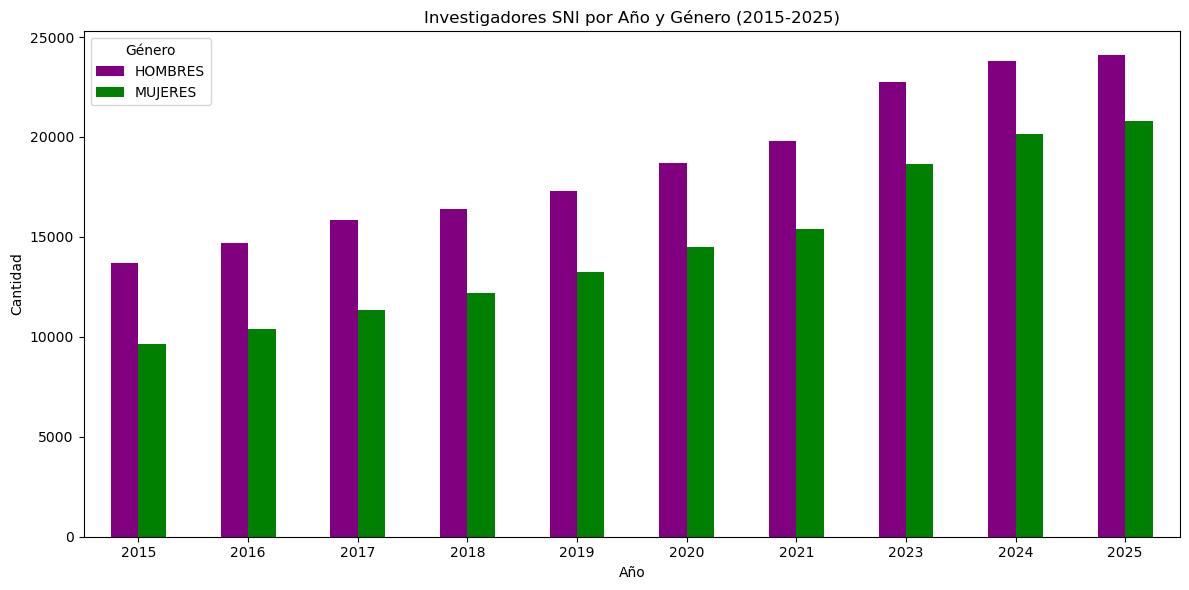

In [5]:
# Gráfico 1: Investigadores por Año y Género
df_resumen[['HOMBRES', 'MUJERES']].plot(kind='bar', figsize=(12,6), color=['purple', 'green'])
plt.title('Investigadores SNI por Año y Género (2015-2025)')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.legend(title='Género')
plt.tight_layout()
plt.savefig('fig_sni/genero_por_anio_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

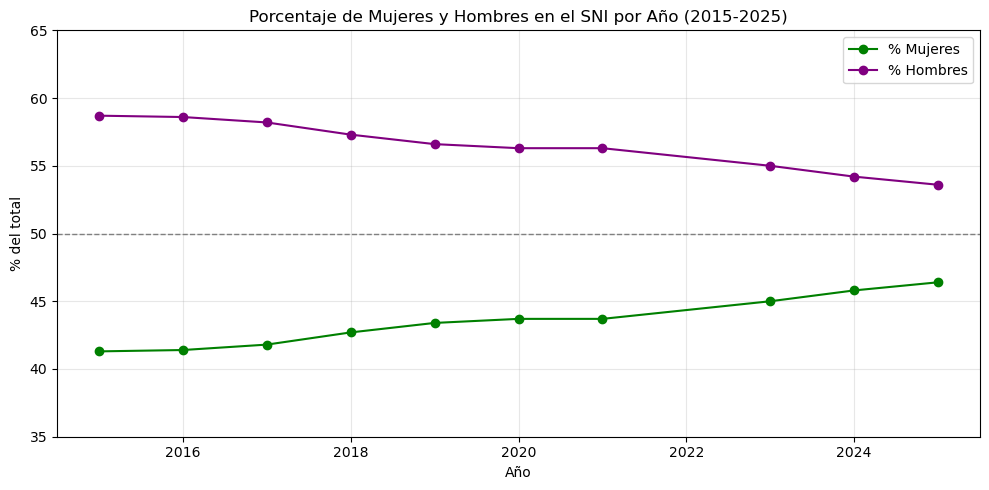

      HOMBRES  MUJERES  TOTAL  % MUJERES  % HOMBRES
AÑO                                                
2015    13691     9624  23315       41.3       58.7
2016    14687    10385  25072       41.4       58.6
2017    15835    11351  27186       41.8       58.2
2018    16415    12218  28633       42.7       57.3
2019    17304    13244  30548       43.4       56.6
2020    18682    14483  33165       43.7       56.3
2021    19794    15384  35178       43.7       56.3
2023    22735    18632  41367       45.0       55.0
2024    23819    20160  43979       45.8       54.2
2025    24080    20809  44889       46.4       53.6


In [6]:
# Gráfico 2: Tendencia del % de Mujeres y Hombres en el SNI
plt.figure(figsize=(10,5))
plt.plot(df_resumen.index, df_resumen['% MUJERES'], marker='o', color='green', label='% Mujeres')
plt.plot(df_resumen.index, df_resumen['% HOMBRES'], marker='o', color='purple', label='% Hombres')
plt.axhline(50, color='gray', linestyle='--', linewidth=1)
plt.title('Porcentaje de Mujeres y Hombres en el SNI por Año (2015-2025)')
plt.xlabel('Año')
plt.ylabel('% del total')
plt.ylim(35, 65)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sni/porcentaje_genero_por_anio_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()
print(df_resumen)

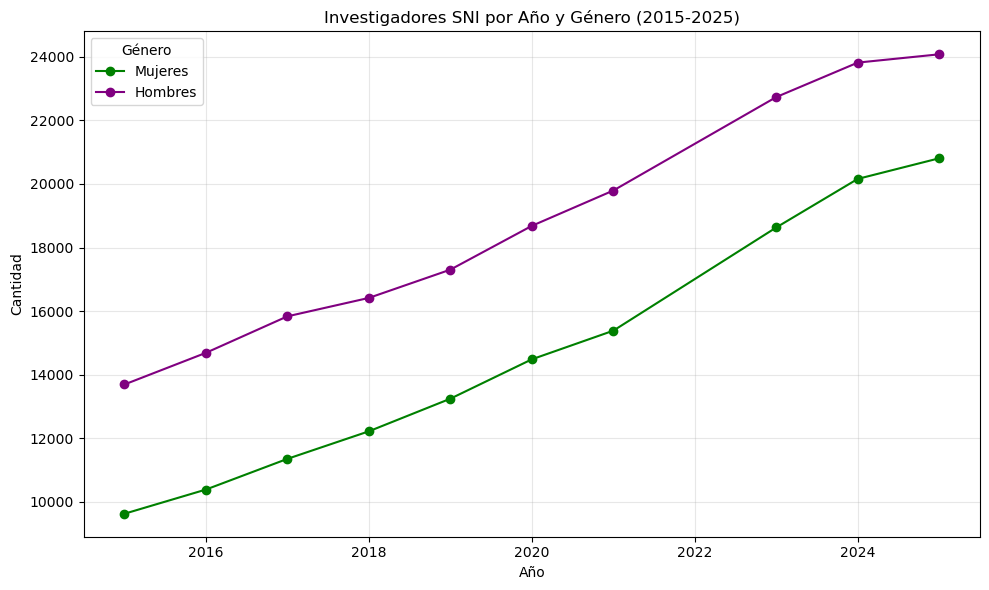

In [7]:
# Gráfico 3: Investigadores por Año y Género (líneas: mujeres en verde, hombres en morado)
plt.figure(figsize=(10,6))
plt.plot(df_resumen.index, df_resumen['MUJERES'], marker='o', color='green', label='Mujeres')
plt.plot(df_resumen.index, df_resumen['HOMBRES'], marker='o', color='purple', label='Hombres')
plt.title('Investigadores SNI por Año y Género (2015-2025)')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.legend(title='Género')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sni/genero_por_anio_lineas_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()


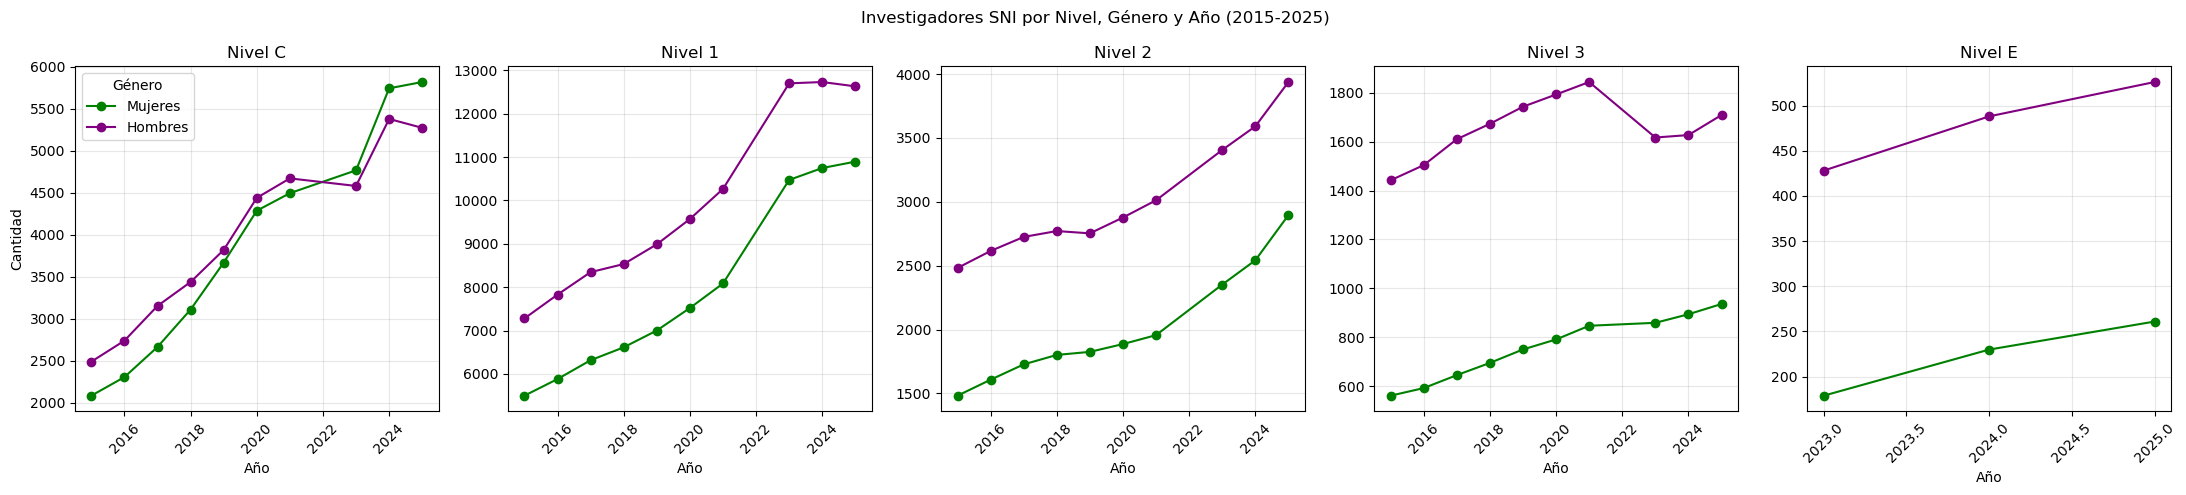

GENERO      DESCONOCIDO  HOMBRE  MUJER
NIVEL AÑO                             
1     2015            0    7278   5497
      2016            0    7828   5880
      2017            0    8347   6315
      2018            0    8533   6612
      2019            0    8988   7000
      2020            0    9572   7519
      2021            0   10266   8085
      2023            0   12702  10474
      2024            0   12733  10749
      2025            0   12633  10896
2     2015            0    2482   1482
      2016            0    2615   1607
      2017            0    2725   1727
      2018            0    2771   1801
      2019            0    2753   1825
      2020            0    2877   1886
      2021            0    3012   1956
      2023            0    3406   2352
      2024            0    3591   2542
      2025            0    3938   2896
3     2015            0    1442    561
      2016            0    1504    592
      2017            0    1610    645
      2018            0  

In [8]:
# Gráfico 4: Investigadores por Nivel, Género y Año
# Nota: el nivel 'E' (Emérito) solo se puede aislar en 2023-2025 con los datos disponibles;
# en 2015-2021 el padrón no distingue Eméritos como categoría propia, así que esas líneas
# quedan sin datos para 'E'.
fig, axes = plt.subplots(1, len(orden_niveles), figsize=(22, 5), sharey=False)

for ax, nivel in zip(axes, orden_niveles):
    datos = df_nivel_genero_anio.loc[nivel] if nivel in df_nivel_genero_anio.index.get_level_values('NIVEL') else None
    if datos is None:
        ax.set_title(f'Nivel {nivel} (sin datos)')
        continue
    ax.plot(datos.index, datos.get('MUJER', 0), marker='o', color='green', label='Mujeres')
    ax.plot(datos.index, datos.get('HOMBRE', 0), marker='o', color='purple', label='Hombres')
    ax.set_title(f'Nivel {nivel}')
    ax.set_xlabel('Año')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Cantidad')
axes[0].legend(title='Género')
fig.suptitle('Investigadores SNI por Nivel, Género y Año (2015-2025)')
plt.tight_layout()
plt.savefig('fig_sni/nivel_genero_por_anio_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

print(df_nivel_genero_anio)


## Solo área Físico-Matemáticas y Ciencias de la Tierra

Mismos cuatro gráficos de arriba, pero filtrando únicamente los registros del área **Físico-Matemáticas y Ciencias de la Tierra**.

La columna de área cambia de formato por año: código numérico `1` en 2015-2019, texto con prefijo de número romano ("I.- FÍSICO-MATEMÁTICAS...") en 2020/2021/2023, y texto plano ("FÍSICO-MATEMÁTICAS Y CIENCIAS DE LA TIERRA") en 2024/2025. `es_fisico_matematicas` cubre los tres casos.

In [9]:
def es_fisico_matematicas(valor):
    v = str(valor).strip().upper()
    if v in ('1', '1.0'):
        return True
    return 'FÍSICO-MATEMÁTICAS' in v or 'FISICO-MATEMATICAS' in v

resumen_fm = []
registros_nivel_fm = []

for year, cfg in sorted(configs.items()):
    df = detalle_por_anio[year]
    es_fm = df[cfg['area_col']].apply(es_fisico_matematicas)
    df_fm = df[es_fm]

    conteo = df_fm['GENERO'].value_counts()
    hombres = int(conteo.get('HOMBRE', 0))
    mujeres = int(conteo.get('MUJER', 0))
    resumen_fm.append({'AÑO': year, 'HOMBRES': hombres, 'MUJERES': mujeres, 'TOTAL': hombres + mujeres})

    nivel = df_fm[cfg['nivel_col']].astype(str).str.strip().str.upper()
    if 'emerito_col' in cfg:
        es_emerito = df_fm[cfg['emerito_col']].astype(str).str.strip().str.upper() == 'EMÉRITO'
        nivel = nivel.where(~es_emerito, 'E')
    nivel = nivel.where(nivel.isin(orden_niveles))
    registros_nivel_fm.append(pd.DataFrame({'AÑO': year, 'NIVEL': nivel, 'GENERO': df_fm['GENERO']}))

df_resumen_fm = pd.DataFrame(resumen_fm).set_index('AÑO')
df_resumen_fm['% MUJERES'] = (100 * df_resumen_fm['MUJERES'] / df_resumen_fm['TOTAL']).round(1)
df_resumen_fm['% HOMBRES'] = (100 * df_resumen_fm['HOMBRES'] / df_resumen_fm['TOTAL']).round(1)
df_resumen_fm.to_csv('datasets/resumen_genero_por_anio_fisico_matematicas.csv')

df_nivel_genero_anio_fm = (
    pd.concat(registros_nivel_fm, ignore_index=True)
    .groupby(['NIVEL', 'AÑO', 'GENERO'])
    .size()
    .unstack('GENERO', fill_value=0)
)
df_nivel_genero_anio_fm.to_csv('datasets/resumen_nivel_genero_por_anio_fisico_matematicas.csv')

df_resumen_fm

,HOMBRES,MUJERES,TOTAL,% MUJERES,% HOMBRES
AÑO,,,,,
2015,2745,1035,3780,27.4,72.6
2016,2882,1112,3994,27.8,72.2
2017,3046,1198,4244,28.2,71.8
2018,3144,1268,4412,28.7,71.3
2019,3316,1392,4708,29.6,70.4
2020,3508,1471,4979,29.5,70.5
2021,3615,1538,5153,29.8,70.2
2023,3724,1649,5373,30.7,69.3
2024,4046,1817,5863,31.0,69.0


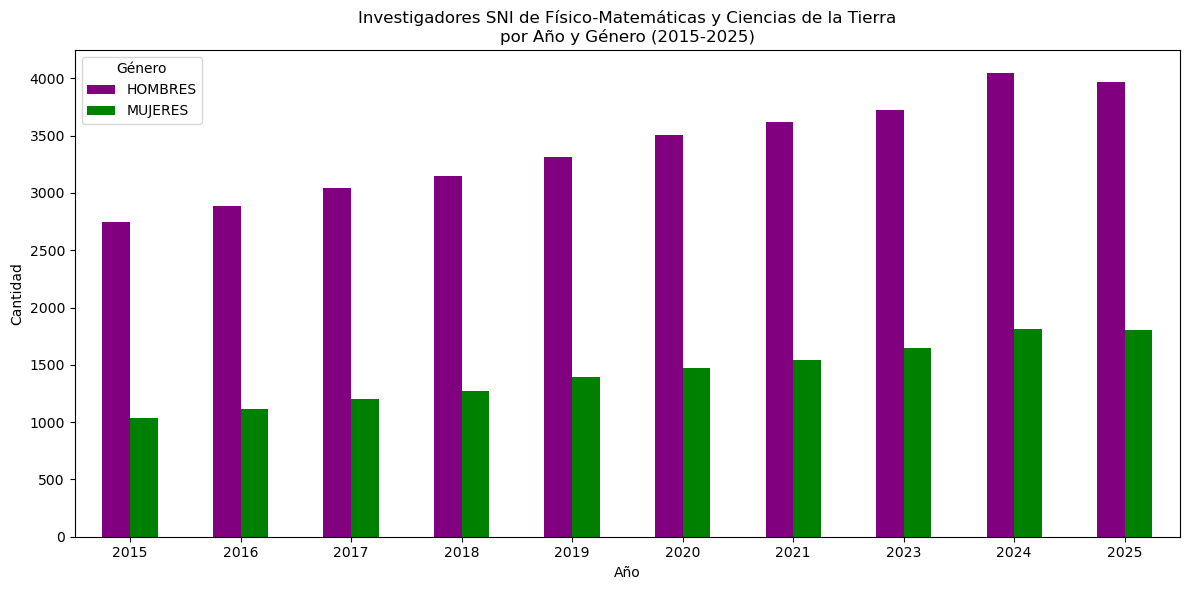

In [10]:
# Gráfico 1 (Físico-Matemáticas): Investigadores por Año y Género
df_resumen_fm[['HOMBRES', 'MUJERES']].plot(kind='bar', figsize=(12,6), color=['purple', 'green'])
plt.title('Investigadores SNI de Físico-Matemáticas y Ciencias de la Tierra\npor Año y Género (2015-2025)')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.legend(title='Género')
plt.tight_layout()
plt.savefig('fig_sni/genero_por_anio_fisico_matematicas_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

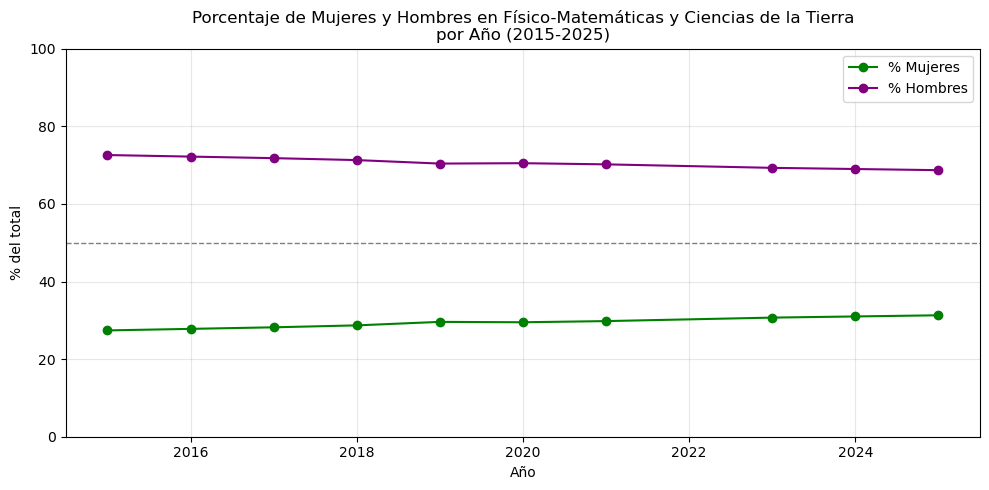

      HOMBRES  MUJERES  TOTAL  % MUJERES  % HOMBRES
AÑO                                                
2015     2745     1035   3780       27.4       72.6
2016     2882     1112   3994       27.8       72.2
2017     3046     1198   4244       28.2       71.8
2018     3144     1268   4412       28.7       71.3
2019     3316     1392   4708       29.6       70.4
2020     3508     1471   4979       29.5       70.5
2021     3615     1538   5153       29.8       70.2
2023     3724     1649   5373       30.7       69.3
2024     4046     1817   5863       31.0       69.0
2025     3965     1806   5771       31.3       68.7


In [11]:
# Gráfico 2 (Físico-Matemáticas): Tendencia del % de Mujeres y Hombres
plt.figure(figsize=(10,5))
plt.plot(df_resumen_fm.index, df_resumen_fm['% MUJERES'], marker='o', color='green', label='% Mujeres')
plt.plot(df_resumen_fm.index, df_resumen_fm['% HOMBRES'], marker='o', color='purple', label='% Hombres')
plt.axhline(50, color='gray', linestyle='--', linewidth=1)
plt.title('Porcentaje de Mujeres y Hombres en Físico-Matemáticas y Ciencias de la Tierra\npor Año (2015-2025)')
plt.xlabel('Año')
plt.ylabel('% del total')
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sni/porcentaje_genero_por_anio_fisico_matematicas_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()
print(df_resumen_fm)

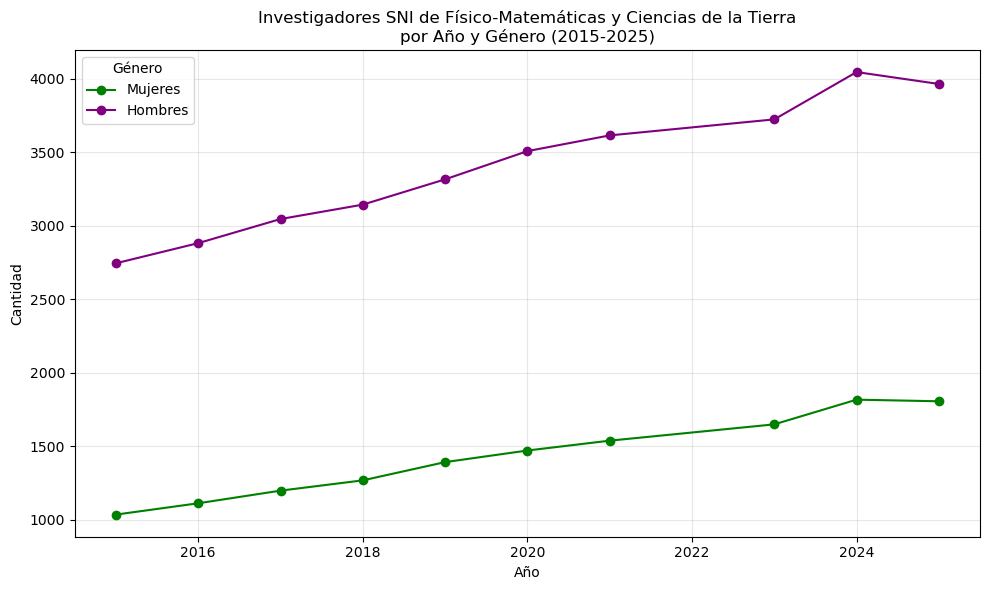

In [12]:
# Gráfico 3 (Físico-Matemáticas): Investigadores por Año y Género (líneas)
plt.figure(figsize=(10,6))
plt.plot(df_resumen_fm.index, df_resumen_fm['MUJERES'], marker='o', color='green', label='Mujeres')
plt.plot(df_resumen_fm.index, df_resumen_fm['HOMBRES'], marker='o', color='purple', label='Hombres')
plt.title('Investigadores SNI de Físico-Matemáticas y Ciencias de la Tierra\npor Año y Género (2015-2025)')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.legend(title='Género')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sni/genero_por_anio_lineas_fisico_matematicas_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

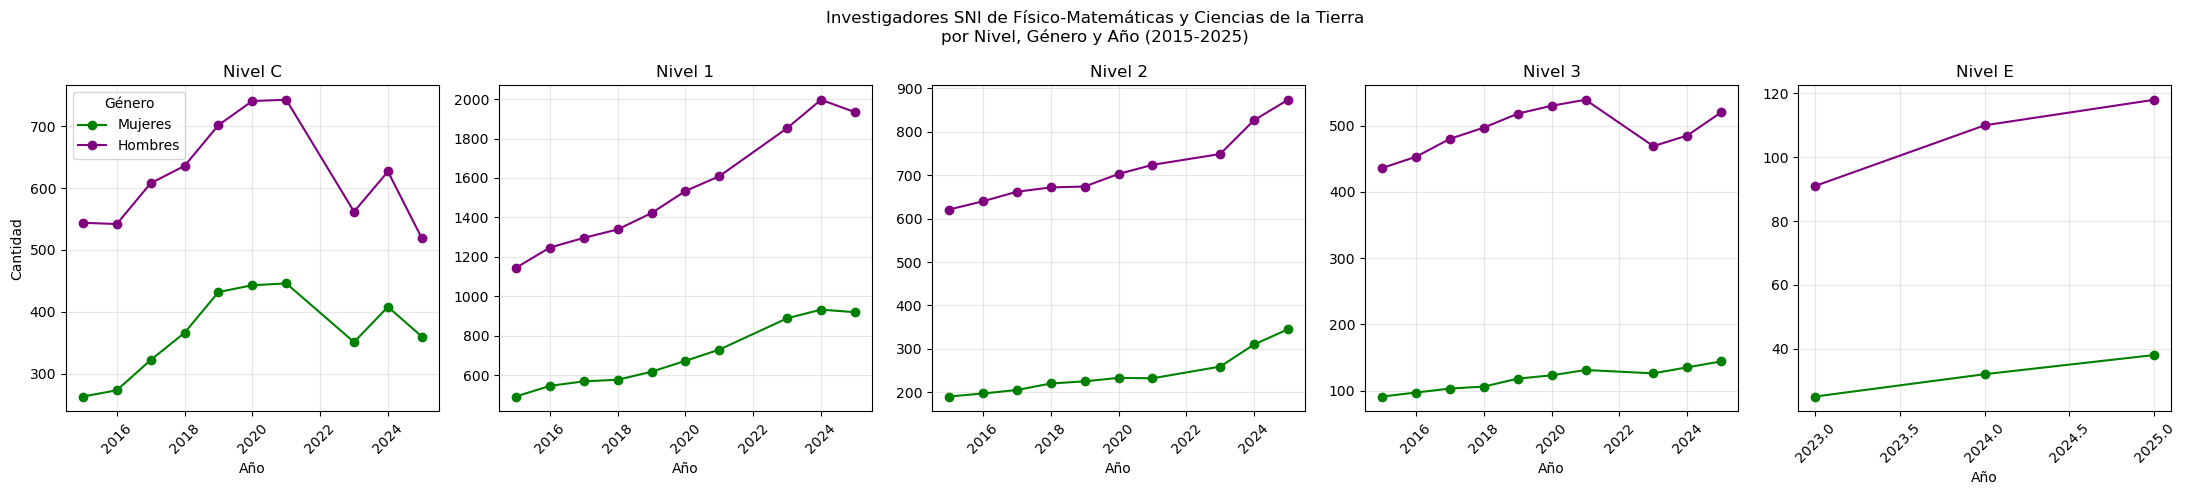

GENERO      HOMBRE  MUJER
NIVEL AÑO                
1     2015    1144    491
      2016    1247    545
      2017    1296    568
      2018    1339    576
      2019    1422    617
      2020    1534    672
      2021    1609    729
      2023    1853    888
      2024    1997    932
      2025    1934    919
2     2015     621    190
      2016     640    197
      2017     662    205
      2018     672    220
      2019     674    225
      2020     703    233
      2021     724    232
      2023     749    259
      2024     827    310
      2025     874    345
3     2015     436     91
      2016     453     97
      2017     480    103
      2018     497    106
      2019     518    118
      2020     530    123
      2021     539    131
      2023     469    126
      2024     485    135
      2025     520    144
C     2015     544    263
      2016     542    273
      2017     608    322
      2018     636    366
      2019     702    432
      2020     741    443
      2021  

In [13]:
# Gráfico 4 (Físico-Matemáticas): por Nivel, Género y Año
fig, axes = plt.subplots(1, len(orden_niveles), figsize=(22, 5), sharey=False)

for ax, nivel in zip(axes, orden_niveles):
    datos = df_nivel_genero_anio_fm.loc[nivel] if nivel in df_nivel_genero_anio_fm.index.get_level_values('NIVEL') else None
    if datos is None:
        ax.set_title(f'Nivel {nivel} (sin datos)')
        continue
    ax.plot(datos.index, datos.get('MUJER', 0), marker='o', color='green', label='Mujeres')
    ax.plot(datos.index, datos.get('HOMBRE', 0), marker='o', color='purple', label='Hombres')
    ax.set_title(f'Nivel {nivel}')
    ax.set_xlabel('Año')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Cantidad')
axes[0].legend(title='Género')
fig.suptitle('Investigadores SNI de Físico-Matemáticas y Ciencias de la Tierra\npor Nivel, Género y Año (2015-2025)')
plt.tight_layout()
plt.savefig('fig_sni/nivel_genero_por_anio_fisico_matematicas_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

print(df_nivel_genero_anio_fm)

## Solo área Ciencias Sociales

Mismos cuatro gráficos, filtrando únicamente los registros del área **Ciencias Sociales**.

Al igual que con Físico-Matemáticas, el código/nombre del área cambia por año: código numérico `5` en 2015-2019 (verificado cruzando con la columna `CAMPO` de 2015: ciencias políticas, sociología, derecho, economía, etc.), y texto plano `"CIENCIAS SOCIALES"` en 2020-2025 (con distinto prefijo de número romano según el año: `V.-` en 2020/2021, `VI.-` en 2023, sin prefijo en 2024/2025 — por eso se hace coincidencia por subcadena en vez de por el número romano).

In [14]:
def es_ciencias_sociales(valor):
    v = str(valor).strip().upper()
    if v in ('5', '5.0'):
        return True
    return 'CIENCIAS SOCIALES' in v

resumen_cs = []
registros_nivel_cs = []

for year, cfg in sorted(configs.items()):
    df = detalle_por_anio[year]
    es_cs = df[cfg['area_col']].apply(es_ciencias_sociales)
    df_cs = df[es_cs]

    conteo = df_cs['GENERO'].value_counts()
    hombres = int(conteo.get('HOMBRE', 0))
    mujeres = int(conteo.get('MUJER', 0))
    resumen_cs.append({'AÑO': year, 'HOMBRES': hombres, 'MUJERES': mujeres, 'TOTAL': hombres + mujeres})

    nivel = df_cs[cfg['nivel_col']].astype(str).str.strip().str.upper()
    if 'emerito_col' in cfg:
        es_emerito = df_cs[cfg['emerito_col']].astype(str).str.strip().str.upper() == 'EMÉRITO'
        nivel = nivel.where(~es_emerito, 'E')
    nivel = nivel.where(nivel.isin(orden_niveles))
    registros_nivel_cs.append(pd.DataFrame({'AÑO': year, 'NIVEL': nivel, 'GENERO': df_cs['GENERO']}))

df_resumen_cs = pd.DataFrame(resumen_cs).set_index('AÑO')
df_resumen_cs['% MUJERES'] = (100 * df_resumen_cs['MUJERES'] / df_resumen_cs['TOTAL']).round(1)
df_resumen_cs['% HOMBRES'] = (100 * df_resumen_cs['HOMBRES'] / df_resumen_cs['TOTAL']).round(1)
df_resumen_cs.to_csv('datasets/resumen_genero_por_anio_ciencias_sociales.csv')

df_nivel_genero_anio_cs = (
    pd.concat(registros_nivel_cs, ignore_index=True)
    .groupby(['NIVEL', 'AÑO', 'GENERO'])
    .size()
    .unstack('GENERO', fill_value=0)
)
df_nivel_genero_anio_cs.to_csv('datasets/resumen_nivel_genero_por_anio_ciencias_sociales.csv')

df_resumen_cs

,HOMBRES,MUJERES,TOTAL,% MUJERES,% HOMBRES
AÑO,,,,,
2015,2099,1574,3673,42.9,57.1
2016,2254,1729,3983,43.4,56.6
2017,2411,1891,4302,44.0,56.0
2018,2527,2084,4611,45.2,54.8
2019,2706,2339,5045,46.4,53.6
2020,2911,2573,5484,46.9,53.1
2021,3151,2786,5937,46.9,53.1
2023,3875,3637,7512,48.4,51.6
2024,4143,4014,8157,49.2,50.8


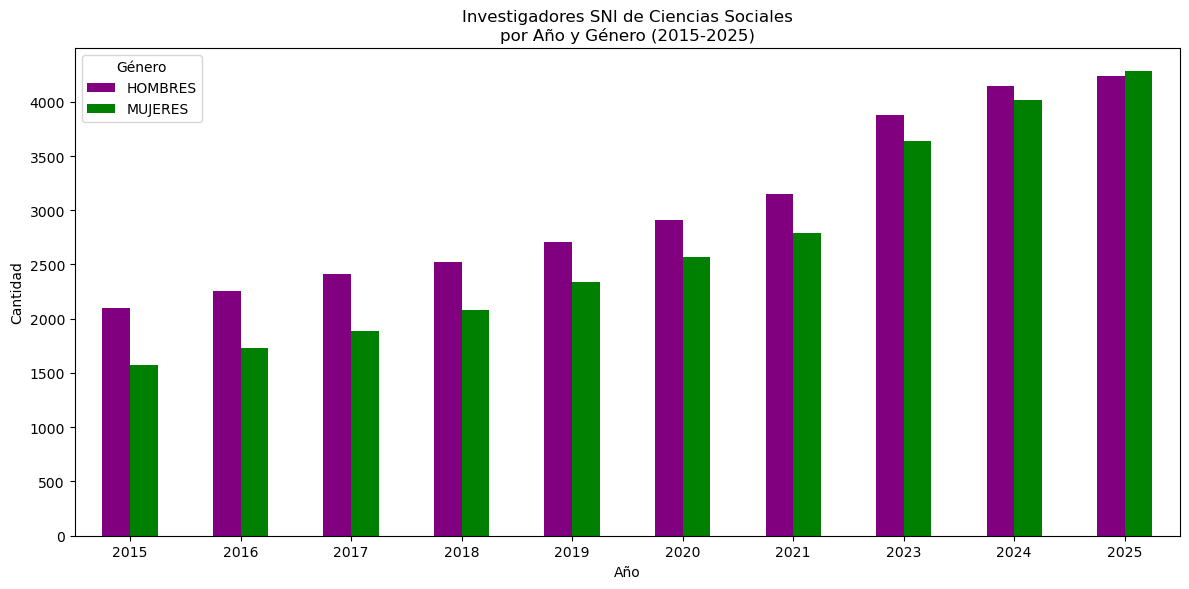

In [15]:
# Gráfico 1 (Ciencias Sociales): Investigadores por Año y Género
df_resumen_cs[['HOMBRES', 'MUJERES']].plot(kind='bar', figsize=(12,6), color=['purple', 'green'])
plt.title('Investigadores SNI de Ciencias Sociales\npor Año y Género (2015-2025)')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.legend(title='Género')
plt.tight_layout()
plt.savefig('fig_sni/genero_por_anio_ciencias_sociales_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

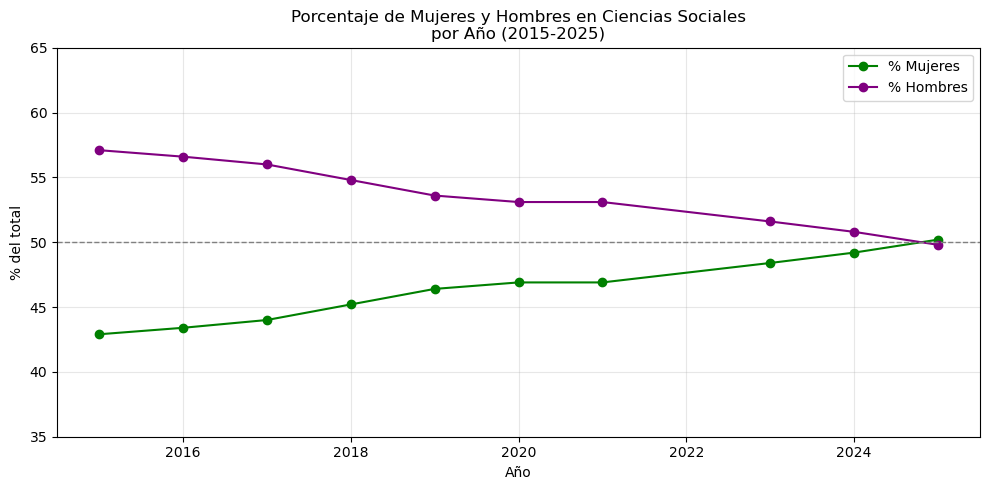

      HOMBRES  MUJERES  TOTAL  % MUJERES  % HOMBRES
AÑO                                                
2015     2099     1574   3673       42.9       57.1
2016     2254     1729   3983       43.4       56.6
2017     2411     1891   4302       44.0       56.0
2018     2527     2084   4611       45.2       54.8
2019     2706     2339   5045       46.4       53.6
2020     2911     2573   5484       46.9       53.1
2021     3151     2786   5937       46.9       53.1
2023     3875     3637   7512       48.4       51.6
2024     4143     4014   8157       49.2       50.8
2025     4241     4282   8523       50.2       49.8


In [16]:
# Gráfico 2 (Ciencias Sociales): Tendencia del % de Mujeres y Hombres
plt.figure(figsize=(10,5))
plt.plot(df_resumen_cs.index, df_resumen_cs['% MUJERES'], marker='o', color='green', label='% Mujeres')
plt.plot(df_resumen_cs.index, df_resumen_cs['% HOMBRES'], marker='o', color='purple', label='% Hombres')
plt.axhline(50, color='gray', linestyle='--', linewidth=1)
plt.title('Porcentaje de Mujeres y Hombres en Ciencias Sociales\npor Año (2015-2025)')
plt.xlabel('Año')
plt.ylabel('% del total')
plt.ylim(35, 65)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sni/porcentaje_genero_por_anio_ciencias_sociales_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()
print(df_resumen_cs)

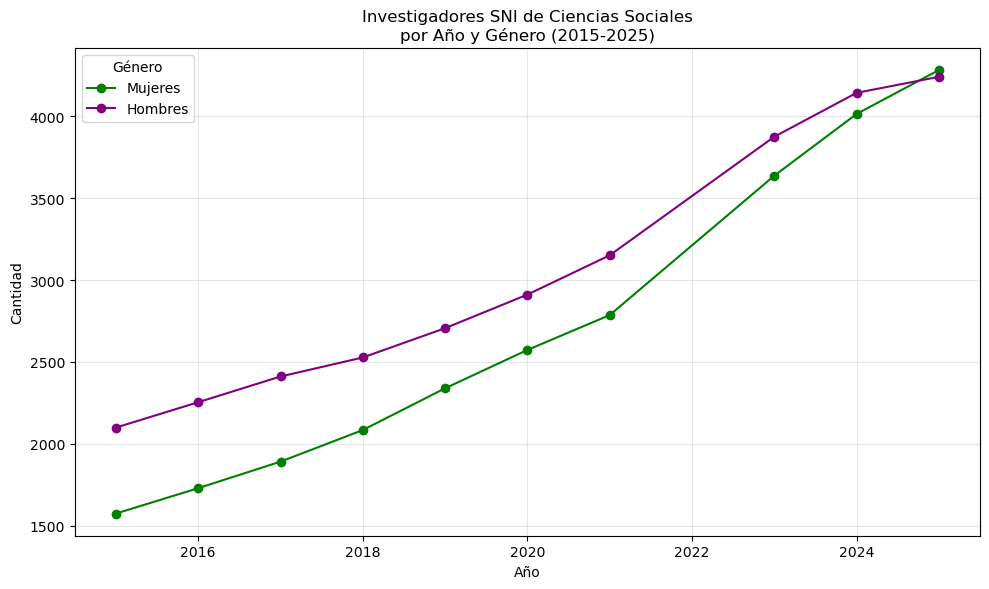

In [17]:
# Gráfico 3 (Ciencias Sociales): Investigadores por Año y Género (líneas)
plt.figure(figsize=(10,6))
plt.plot(df_resumen_cs.index, df_resumen_cs['MUJERES'], marker='o', color='green', label='Mujeres')
plt.plot(df_resumen_cs.index, df_resumen_cs['HOMBRES'], marker='o', color='purple', label='Hombres')
plt.title('Investigadores SNI de Ciencias Sociales\npor Año y Género (2015-2025)')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.legend(title='Género')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_sni/genero_por_anio_lineas_ciencias_sociales_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

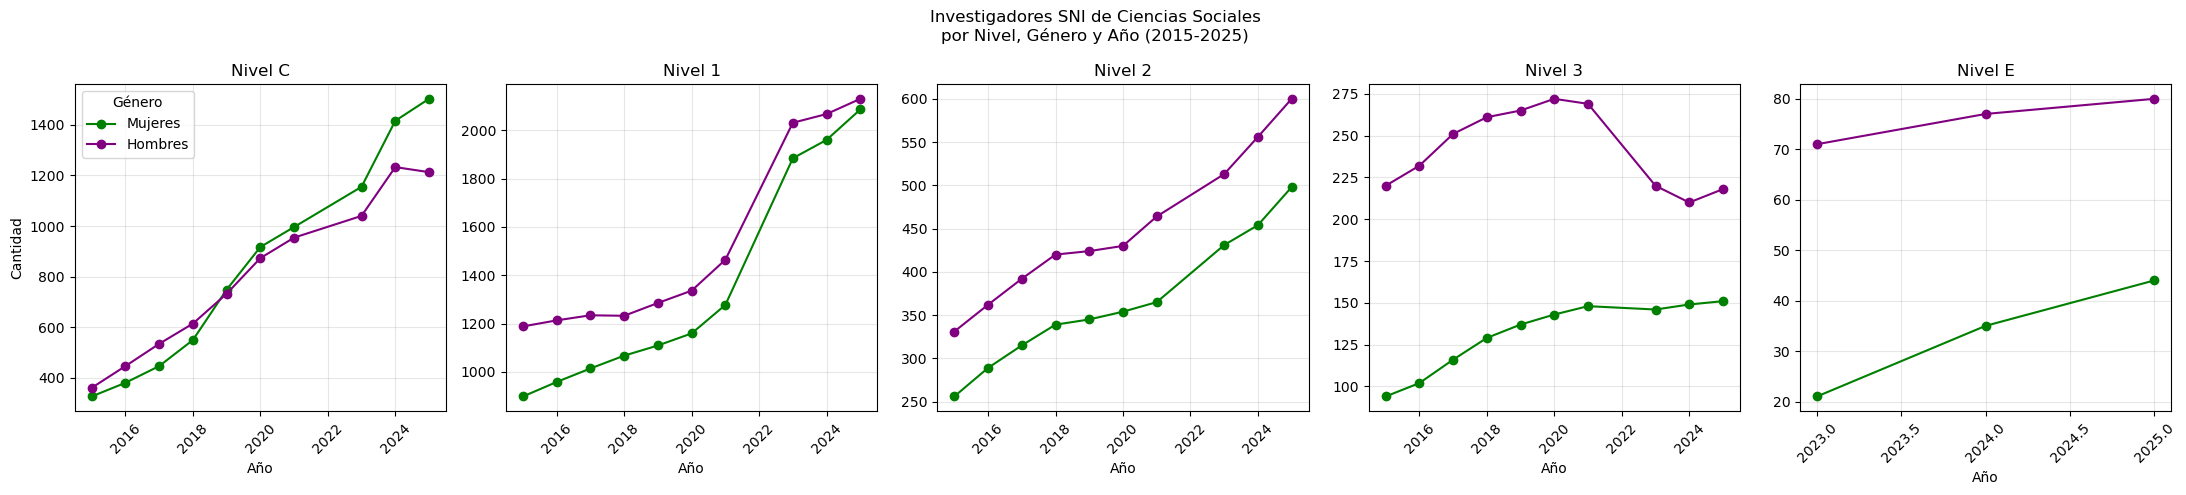

GENERO      HOMBRE  MUJER
NIVEL AÑO                
1     2015    1188    898
      2016    1213    958
      2017    1234   1014
      2018    1232   1067
      2019    1285   1109
      2020    1336   1159
      2021    1464   1277
      2023    2031   1884
      2024    2067   1960
      2025    2130   2086
2     2015     331    256
      2016     362    289
      2017     392    315
      2018     420    339
      2019     424    345
      2020     430    354
      2021     464    365
      2023     513    431
      2024     556    454
      2025     600    498
3     2015     220     94
      2016     232    102
      2017     251    116
      2018     261    129
      2019     265    137
      2020     272    143
      2021     269    148
      2023     220    146
      2024     210    149
      2025     218    151
C     2015     360    326
      2016     446    380
      2017     534    446
      2018     614    549
      2019     732    748
      2020     873    917
      2021  

In [18]:
# Gráfico 4 (Ciencias Sociales): por Nivel, Género y Año
fig, axes = plt.subplots(1, len(orden_niveles), figsize=(22, 5), sharey=False)

for ax, nivel in zip(axes, orden_niveles):
    datos = df_nivel_genero_anio_cs.loc[nivel] if nivel in df_nivel_genero_anio_cs.index.get_level_values('NIVEL') else None
    if datos is None:
        ax.set_title(f'Nivel {nivel} (sin datos)')
        continue
    ax.plot(datos.index, datos.get('MUJER', 0), marker='o', color='green', label='Mujeres')
    ax.plot(datos.index, datos.get('HOMBRE', 0), marker='o', color='purple', label='Hombres')
    ax.set_title(f'Nivel {nivel}')
    ax.set_xlabel('Año')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Cantidad')
axes[0].legend(title='Género')
fig.suptitle('Investigadores SNI de Ciencias Sociales\npor Nivel, Género y Año (2015-2025)')
plt.tight_layout()
plt.savefig('fig_sni/nivel_genero_por_anio_ciencias_sociales_2015_2025.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

print(df_nivel_genero_anio_cs)

## Spider web: Nivel por Área y Género, cada año (2015-2025)

Igual que el panel anterior pero repetido para **cada año** de la serie histórica (2015-2025, sin 2022): un gráfico de telaraña por nivel (**C**, **1**, **2**, **3**, **E**) que compara área de conocimiento y género.

**Reto de comparabilidad entre años:** el padrón del SNI cambió su taxonomía de áreas en 2023, de 7 a 9 áreas:
- El área IV *"Humanidades y Ciencias de la Conducta"* (2015-2021) se dividió en dos áreas independientes desde 2023: *"Ciencias de la Conducta y la Educación"* y *"Humanidades"*.
- El área VI *"Biotecnología y Ciencias Agropecuarias"* (2015-2021) se renombró a *"Ciencias de Agricultura, Agropecuarias, Forestales y de Ecosistemas"* (2023+).
- El área VII *"Ingenierías"* (2015-2021) se renombró a *"Ingenierías y Desarrollo Tecnológico"* (2023+).
- Se agregó una nueva área IX *"Interdisciplinaria"*, que no existía antes de 2023.

Para poder comparar la serie completa con los mismos 8 ejes en todos los años, `area_canonica()` fusiona las dos sub-áreas post-2023 de vuelta en **"Humanidades y Ciencias de la Conducta"** (como en 2015-2021), trata los renombres VI/VII como el mismo eje, y agrega **"Interdisciplinaria"** como un octavo eje que legítimamente vale 0 en 2015-2021 (esa categoría no existía como opción, no es un dato faltante). También cubre los códigos numéricos `1`-`7` de 2015-2019 (validados ya en las secciones de Físico-Matemáticas y Ciencias Sociales de arriba) y descarta valores atípicos de captura (p. ej. `'****'` en 2019, o el código `'C'` que aparece por error en 2 registros de 2015).

In [19]:
def area_canonica(valor):
    v = str(valor).strip().upper()
    if v in ('1', '1.0'):
        return 'FÍSICO-MATEMÁTICAS Y CIENCIAS DE LA TIERRA'
    if v in ('2', '2.0'):
        return 'BIOLOGÍA Y QUÍMICA'
    if v in ('3', '3.0'):
        return 'MEDICINA Y CIENCIAS DE LA SALUD'
    if v in ('4', '4.0'):
        return 'HUMANIDADES Y CIENCIAS DE LA CONDUCTA'
    if v in ('5', '5.0'):
        return 'CIENCIAS SOCIALES'
    if v in ('6', '6.0'):
        return 'BIOTECNOLOGÍA Y CIENCIAS AGROPECUARIAS'
    if v in ('7', '7.0'):
        return 'INGENIERÍAS'
    if 'FÍSICO-MATEMÁTICAS' in v or 'FISICO-MATEMATICAS' in v:
        return 'FÍSICO-MATEMÁTICAS Y CIENCIAS DE LA TIERRA'
    if 'BIOLOGÍA Y QUÍMICA' in v or 'BIOLOGIA Y QUIMICA' in v:
        return 'BIOLOGÍA Y QUÍMICA'
    if 'MEDICINA' in v:
        return 'MEDICINA Y CIENCIAS DE LA SALUD'
    if 'HUMANIDADES' in v or 'CIENCIAS DE LA CONDUCTA' in v:
        return 'HUMANIDADES Y CIENCIAS DE LA CONDUCTA'
    if 'CIENCIAS SOCIALES' in v:
        return 'CIENCIAS SOCIALES'
    if 'BIOTECNOLOGÍA' in v or 'BIOTECNOLOGIA' in v or 'AGROPECUARIAS' in v or 'AGRICULTURA' in v:
        return 'BIOTECNOLOGÍA Y CIENCIAS AGROPECUARIAS'
    if 'INGENIERÍAS' in v or 'INGENIERIAS' in v:
        return 'INGENIERÍAS'
    if 'INTERDISCIPLINARIA' in v:
        return 'INTERDISCIPLINARIA'
    return None

areas_canonicas = [
    'FÍSICO-MATEMÁTICAS Y CIENCIAS DE LA TIERRA',
    'BIOLOGÍA Y QUÍMICA',
    'MEDICINA Y CIENCIAS DE LA SALUD',
    'HUMANIDADES Y CIENCIAS DE LA CONDUCTA',
    'CIENCIAS SOCIALES',
    'BIOTECNOLOGÍA Y CIENCIAS AGROPECUARIAS',
    'INGENIERÍAS',
    'INTERDISCIPLINARIA',
]

registros_area_nivel = []
for year, cfg in sorted(configs.items()):
    df = detalle_por_anio[year]
    area = df[cfg['area_col']].apply(area_canonica)

    nivel = df[cfg['nivel_col']].astype(str).str.strip().str.upper()
    if 'emerito_col' in cfg:
        es_emerito = df[cfg['emerito_col']].astype(str).str.strip().str.upper() == 'EMÉRITO'
        nivel = nivel.where(~es_emerito, 'E')
    nivel = nivel.where(nivel.isin(orden_niveles))

    registros_area_nivel.append(pd.DataFrame({'AÑO': year, 'AREA': area, 'NIVEL': nivel, 'GENERO': df['GENERO']}))

df_area_nivel_genero_anio = (
    pd.concat(registros_area_nivel, ignore_index=True)
    .dropna(subset=['AREA', 'NIVEL'])
    .groupby(['AÑO', 'AREA', 'NIVEL', 'GENERO'])
    .size()
    .unstack('GENERO', fill_value=0)
)
df_area_nivel_genero_anio.to_csv('datasets/resumen_area_nivel_genero_por_anio.csv')
df_area_nivel_genero_anio

GENERO                                             HOMBRE  MUJER
AÑO  AREA                                   NIVEL               
2015 BIOLOGÍA Y QUÍMICA                     1        1068   1004
                                            2         390    255
                                            3         231    119
                                            C         432    489
     BIOTECNOLOGÍA Y CIENCIAS AGROPECUARIAS 1         891    593
...                                                   ...    ...
2025 MEDICINA Y CIENCIAS DE LA SALUD        1        1057   1302
                                            2         348    433
                                            3         188    145
                                            C         495    601
                                            E          74     37

[314 rows x 2 columns]

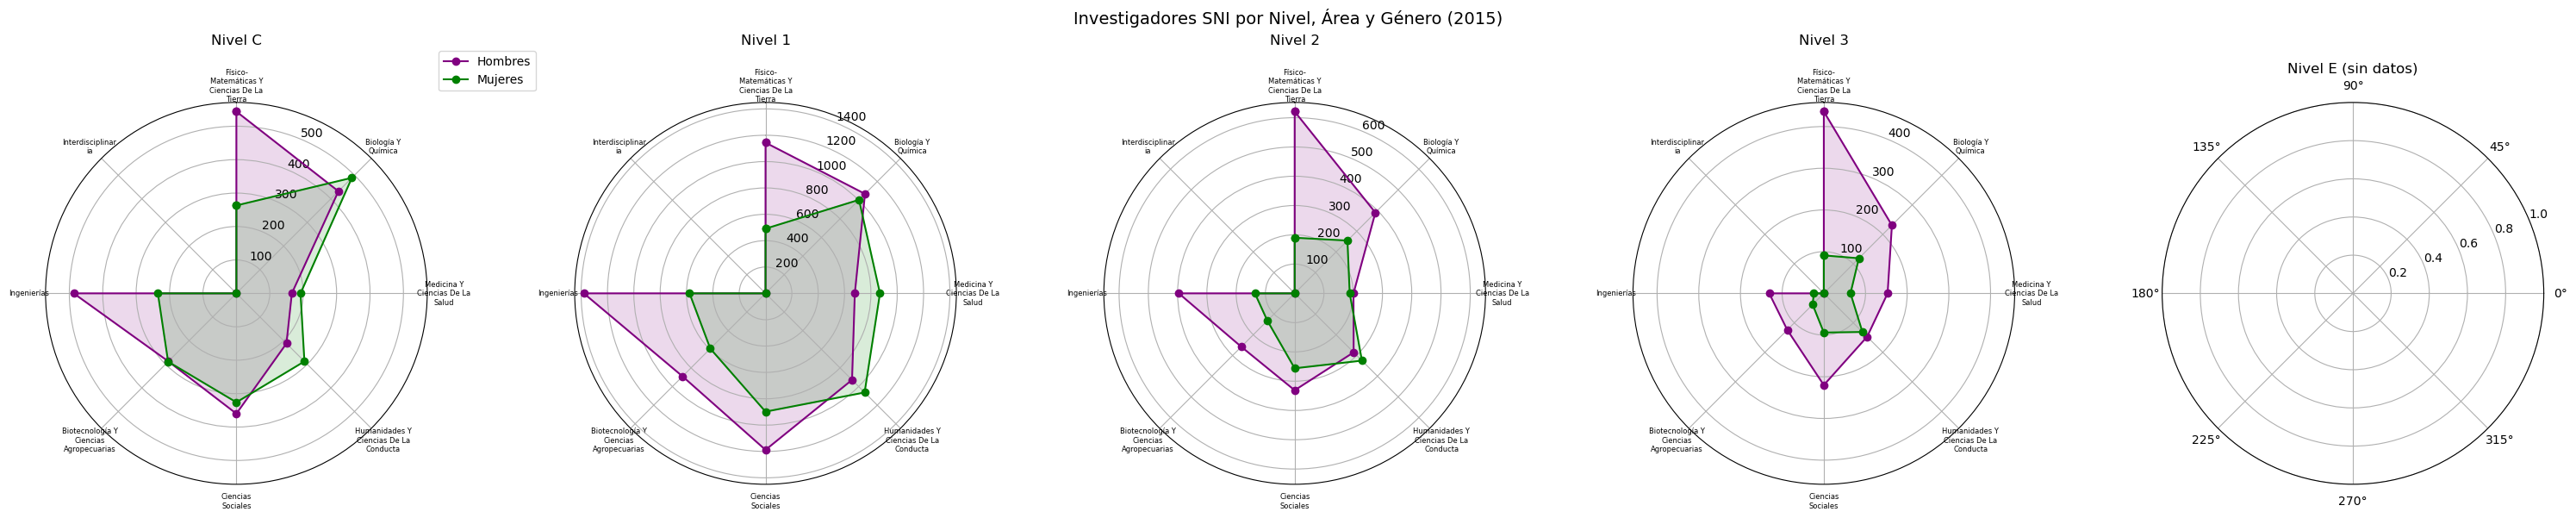

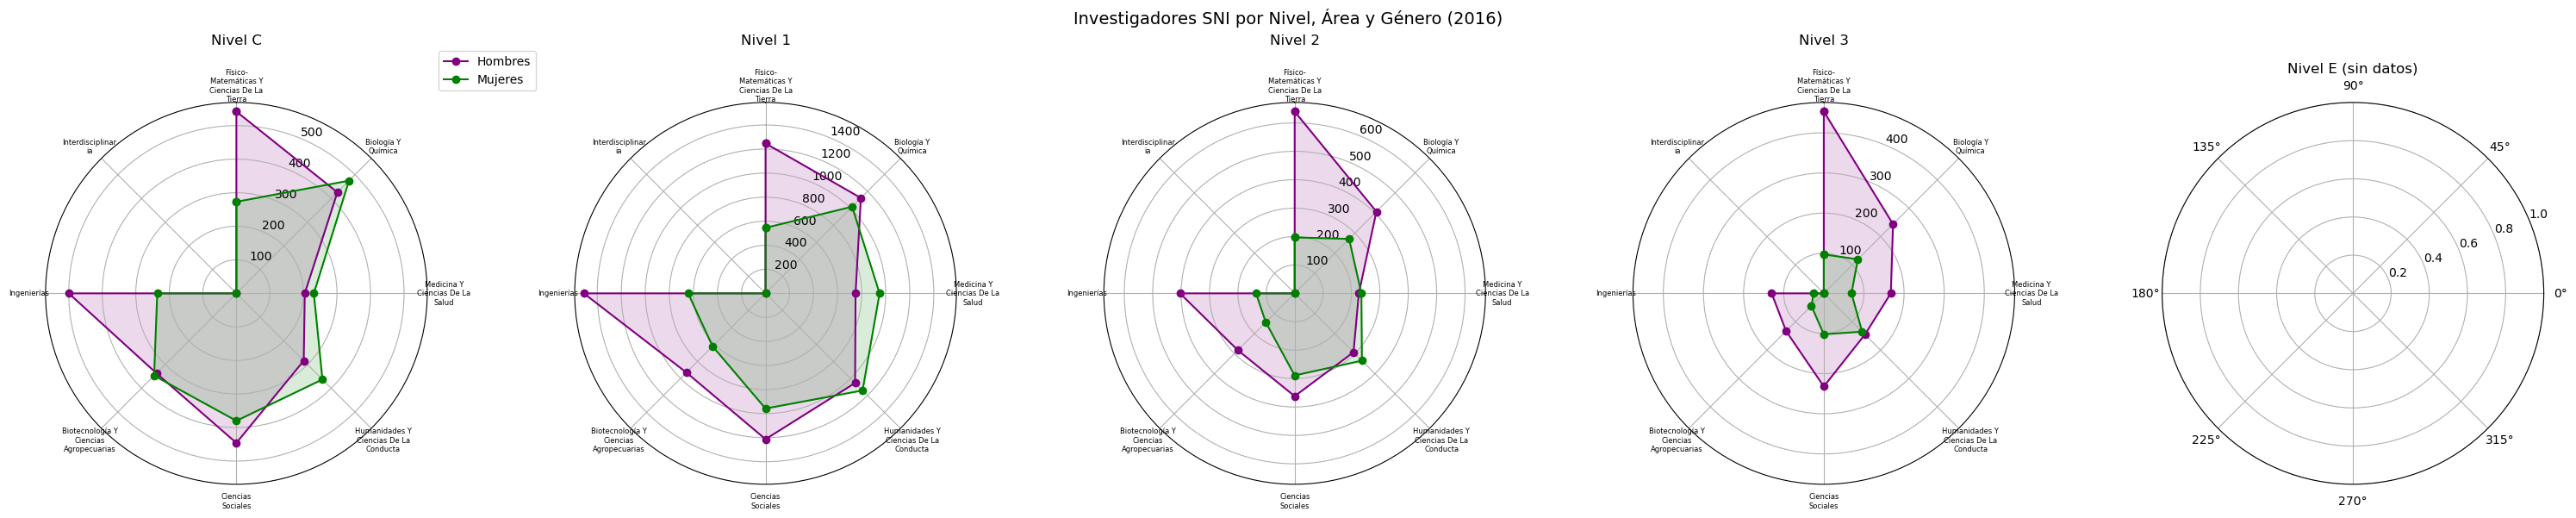

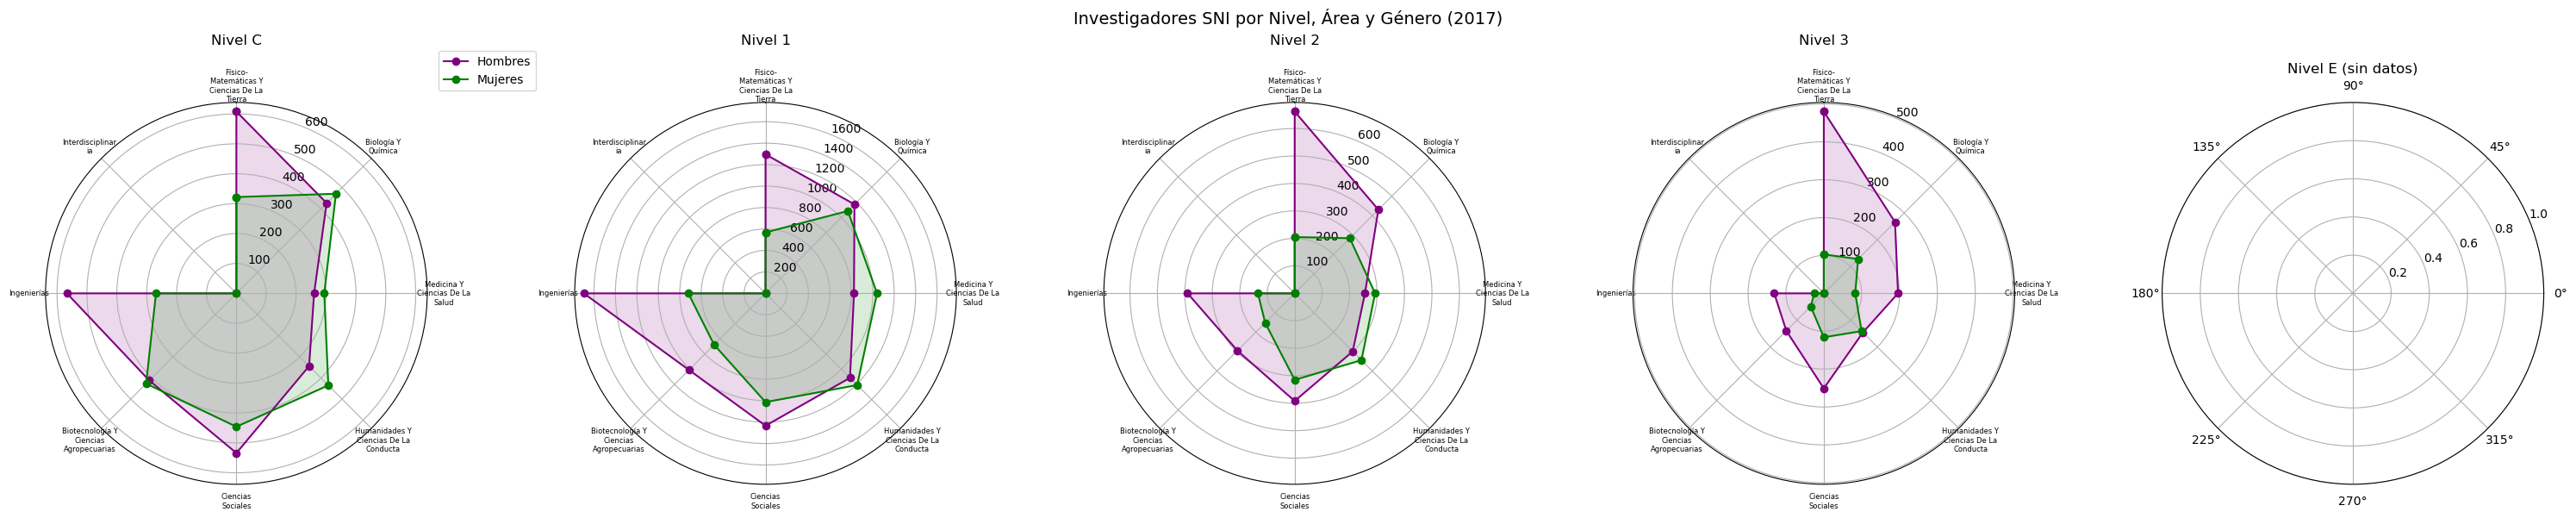

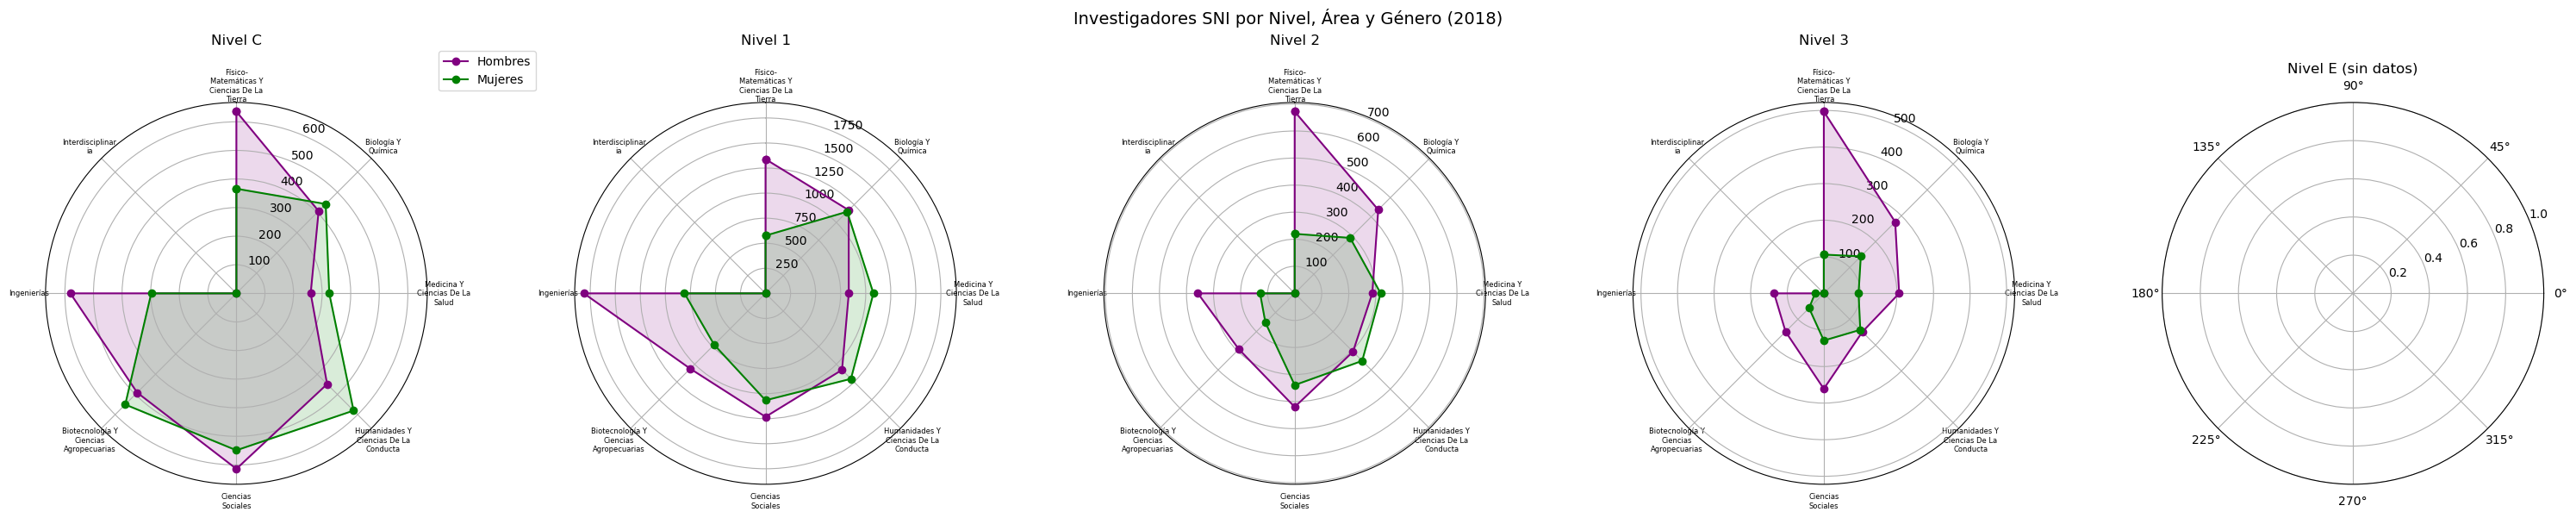

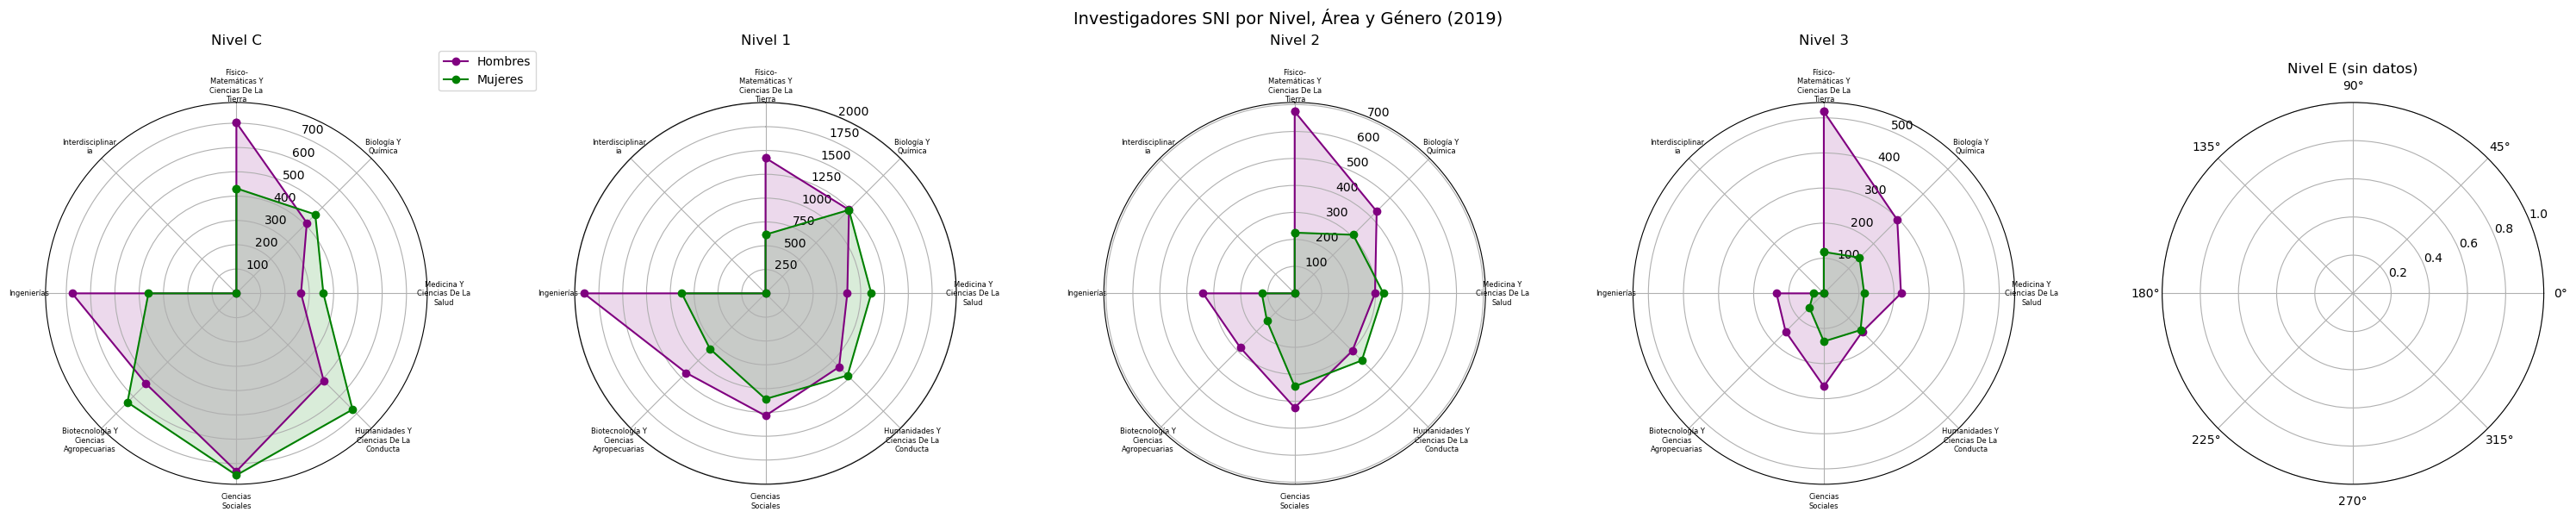

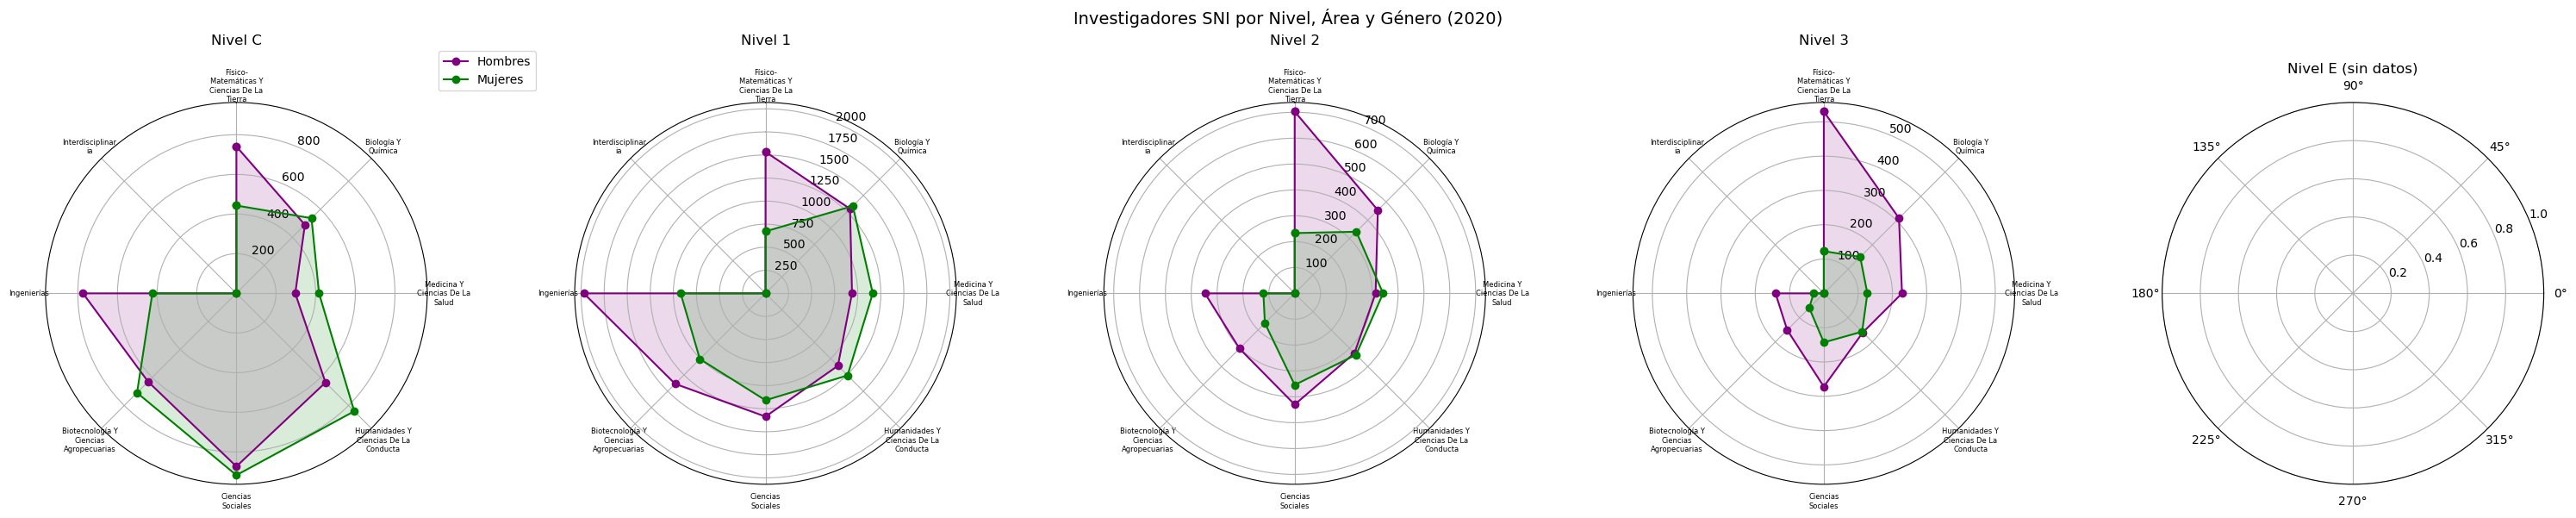

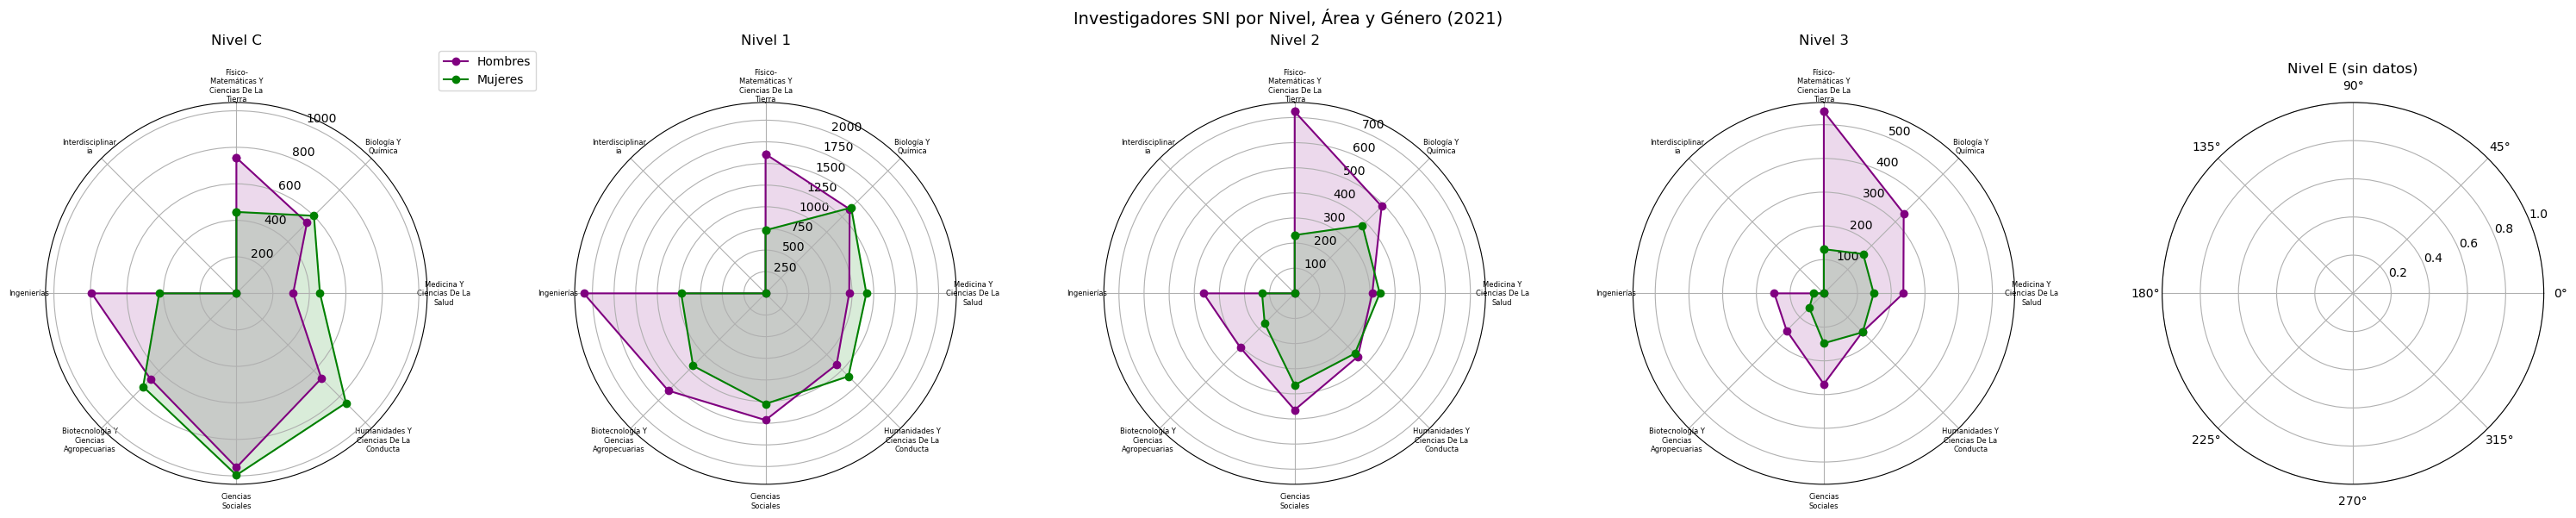

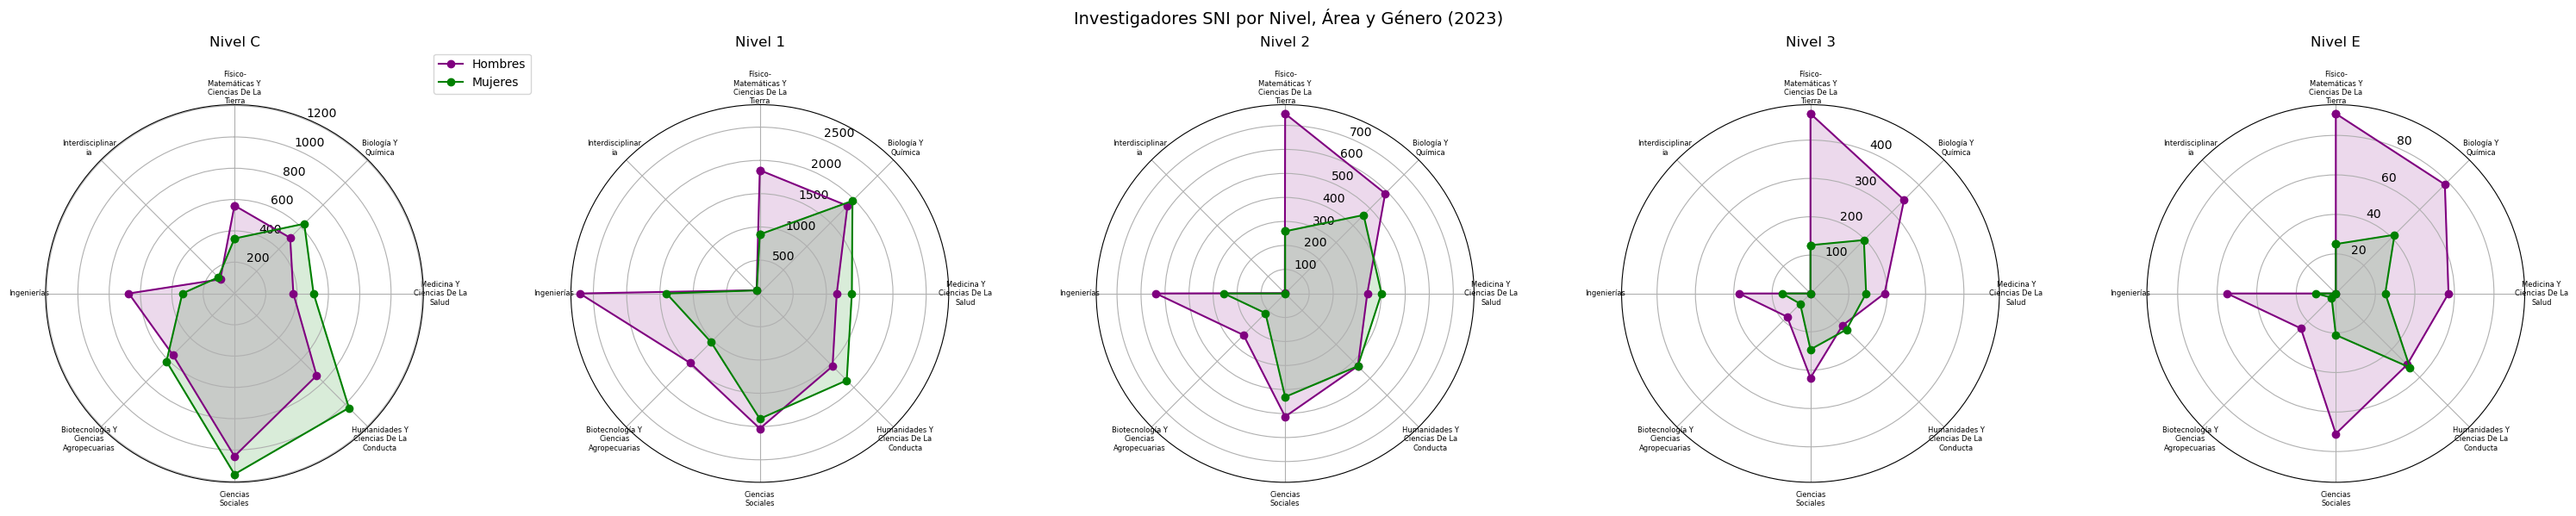

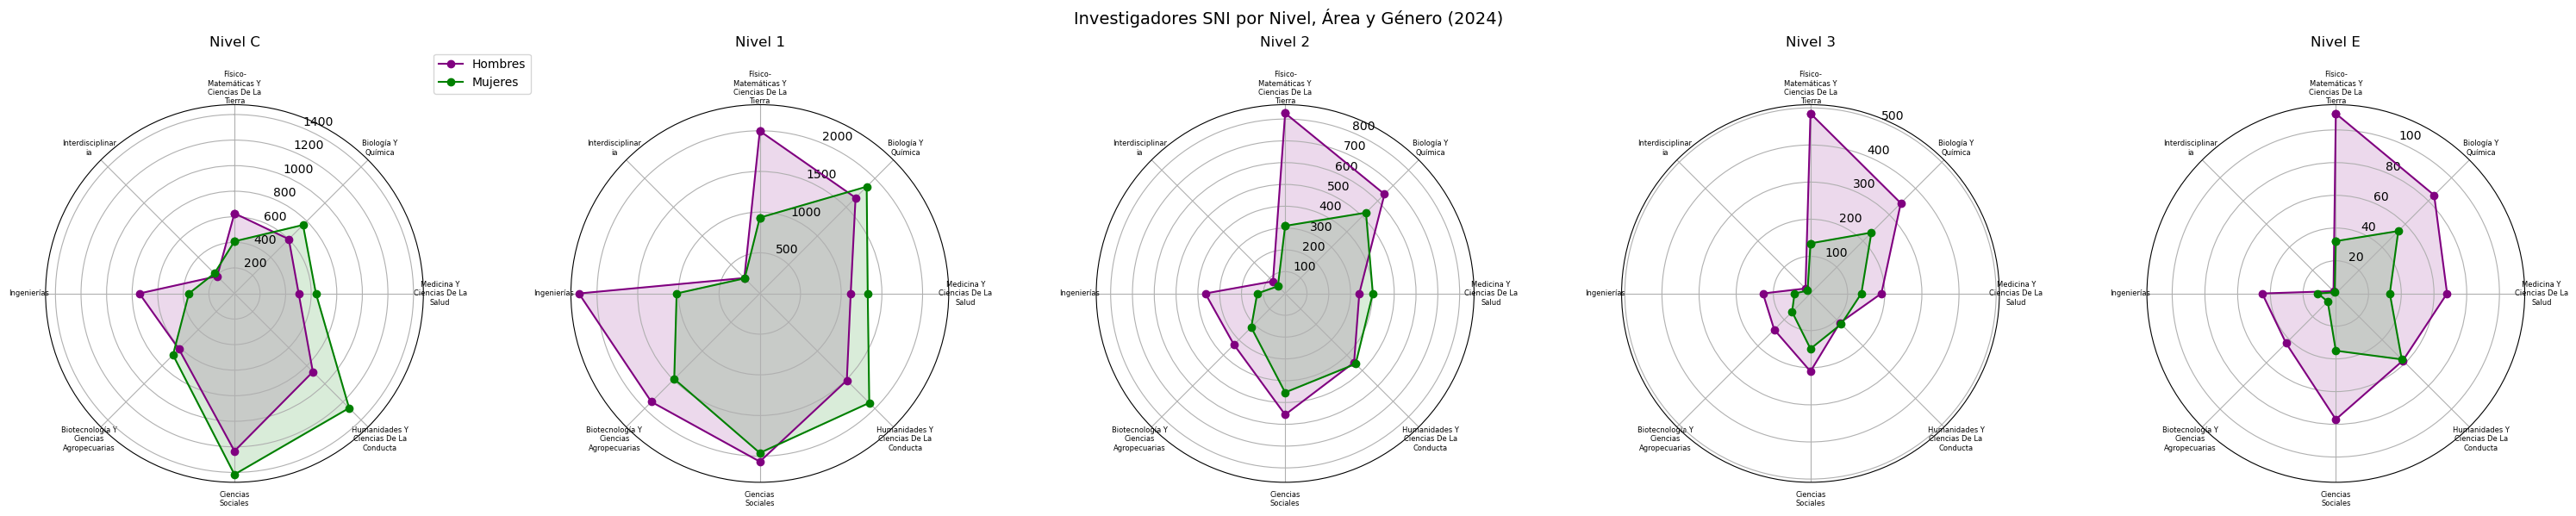

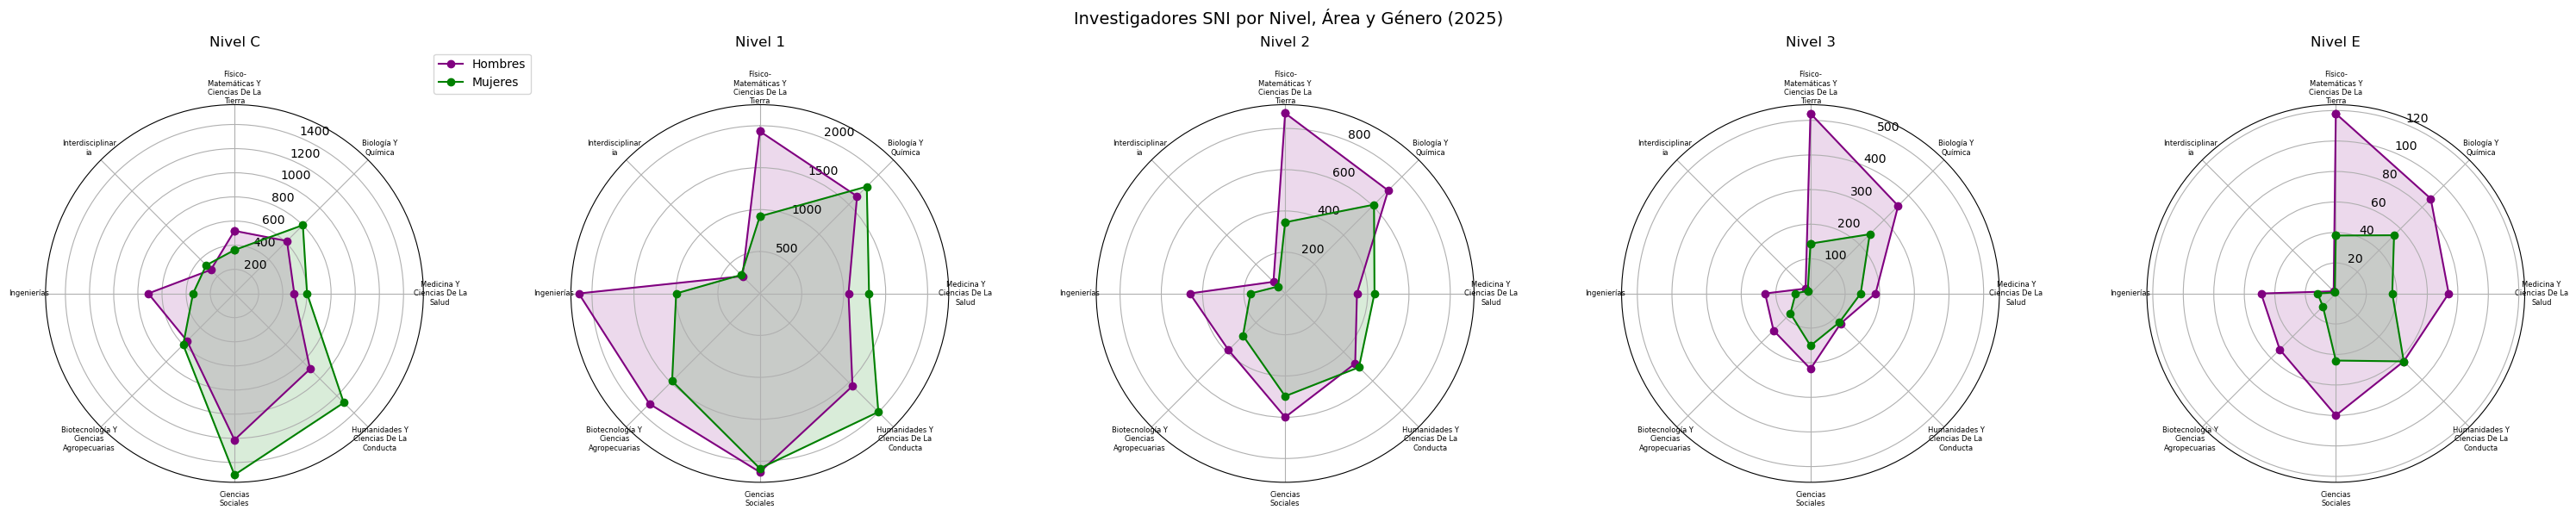

In [20]:
# Gráfico 5: Spider web (radar) por Nivel, Área y Género -- un panel de 5 gráficos por año
import numpy as np
import textwrap

etiquetas = ['\n'.join(textwrap.wrap(a.title(), 16)) for a in areas_canonicas]
n = len(areas_canonicas)
angulos = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angulos += angulos[:1]

for year in sorted(configs.keys()):
    datos_anio = df_area_nivel_genero_anio.loc[year]

    fig, axes = plt.subplots(1, len(orden_niveles), figsize=(30, 6), subplot_kw=dict(polar=True))

    for ax, nivel in zip(axes, orden_niveles):
        if nivel not in datos_anio.index.get_level_values('NIVEL'):
            ax.set_title(f'Nivel {nivel} (sin datos)')
            continue
        datos = datos_anio.xs(nivel, level='NIVEL').reindex(areas_canonicas, fill_value=0)
        valores_h = datos.get('HOMBRE', pd.Series(0, index=areas_canonicas)).tolist()
        valores_h += valores_h[:1]
        valores_m = datos.get('MUJER', pd.Series(0, index=areas_canonicas)).tolist()
        valores_m += valores_m[:1]

        ax.plot(angulos, valores_h, marker='o', color='purple', label='Hombres')
        ax.fill(angulos, valores_h, color='purple', alpha=0.15)
        ax.plot(angulos, valores_m, marker='o', color='green', label='Mujeres')
        ax.fill(angulos, valores_m, color='green', alpha=0.15)

        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_xticks(angulos[:-1])
        ax.set_xticklabels(etiquetas, fontsize=6)
        ax.set_title(f'Nivel {nivel}', pad=20)

    axes[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.15))
    fig.suptitle(f'Investigadores SNI por Nivel, Área y Género ({year})', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'fig_sni/spider_nivel_area_genero_{year}.jpg', format='jpg', dpi=300, bbox_inches='tight')
    plt.show()